In [1]:
# we will be plotting with matplotlib again
# To avoid typing out its full lengthy name again we will use the alias plt
import matplotlib.pyplot as plt

Text(0, 0.5, 'Position (km)')

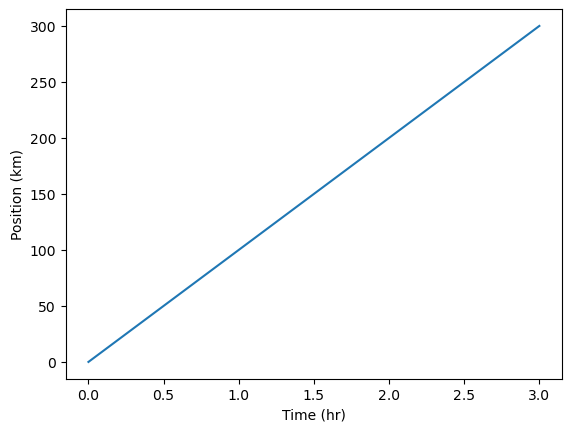

In [2]:
# First up we make some data to use
time = [0,1,2,3]
position = [0,100,200,300]
# This is a simple line graph with labels on the x and y axes
plt.plot(time, position)
plt.xlabel("Time (hr)")
plt.ylabel("Position (km)")

In [6]:
# We will now plot from a pandas dataframe directly
# remember to import pandas with its alias
import pandas as pd
# This time we use the oceania data again and set the index as the country column
data = pd.read_csv("data/gapminder_gdp_oceania.csv", index_col="country")
data

,gdpPercap_1952,gdpPercap_1957,gdpPercap_1962,gdpPercap_1967,gdpPercap_1972,gdpPercap_1977,gdpPercap_1982,gdpPercap_1987,gdpPercap_1992,gdpPercap_1997,gdpPercap_2002,gdpPercap_2007
country,,,,,,,,,,,,
Australia,10039.59564,10949.64959,12217.22686,14526.12465,16788.62948,18334.19751,19477.00928,21888.88903,23424.76683,26997.93657,30687.75473,34435.36744
New Zealand,10556.57566,12247.39532,13175.67800,14463.91893,16046.03728,16233.71770,17632.41040,19007.19129,18363.32494,21050.41377,23189.80135,25185.00911


In [7]:
# Looking at the column name it gives a good amount of context, but if we wanted to use them to label our plot it is a bit messy
# We can change the name of the columns though
# First we treat the entries of the column array as strings (text) and then replace the part we don't want with a part we do
# In this case we replace "gdpPercap_" with "" (an empty string)
years = data.columns.str.replace("gdpPercap_", "")
# in this step we change the entries to integers to allow matplotlib to be able to work with it
# python and matplotlib understand how numbers work and relate to each other, but not text/strings
# when the column names are strings it is the same as them being "stacy", "ian", "duncan", "marina", etc
data.columns = years.astype(int)

In [8]:
# we marvel at our work
data

,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007
country,,,,,,,,,,,,
Australia,10039.59564,10949.64959,12217.22686,14526.12465,16788.62948,18334.19751,19477.00928,21888.88903,23424.76683,26997.93657,30687.75473,34435.36744
New Zealand,10556.57566,12247.39532,13175.67800,14463.91893,16046.03728,16233.71770,17632.41040,19007.19129,18363.32494,21050.41377,23189.80135,25185.00911


<Axes: >

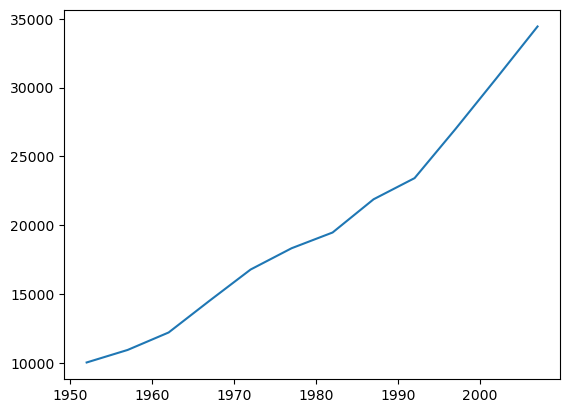

In [9]:
# Let's plot Australia from the data (plot gives a basic line plot)
data.loc["Australia"].plot()

Text(0, 0.5, 'GDP per capita')

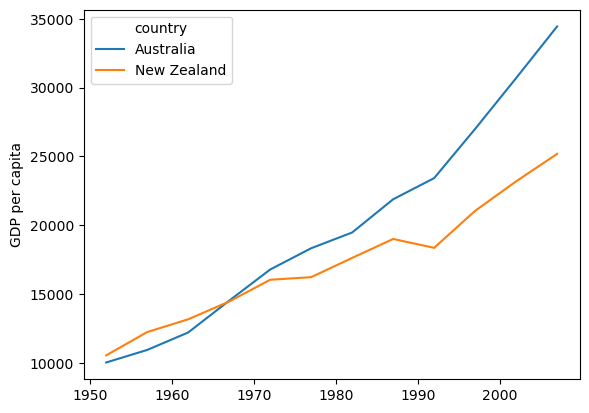

In [10]:
# We can also plot mulitple countries together
# our data has the country as the index, so if we tranpose our data they become the columns
# Now when we plot it give a line per column and takes the year as the x value and gdp as the y
data.T.plot()
# Adding a label to make clear which value is which
plt.ylabel("GDP per capita")

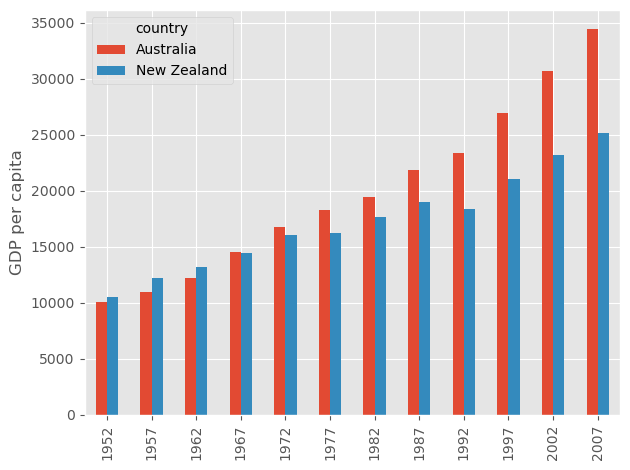

In [12]:
# matplotlib has some inbuilt pre-formed styles, such as ggplot (the commonly used plotting library in R)
plt.style.use("ggplot")
# We can also set the type of plot we want by using the kind argument, we want a bar chart
data.T.plot(kind="bar")
plt.ylabel("GDP per capita")
# remove the line of text that appears before our plots with this additional command
# it does more things, but in this case it only really removes the text for us
plt.tight_layout()

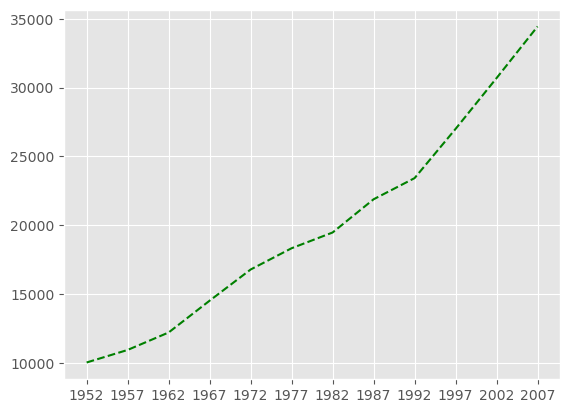

In [13]:
# let's make a new plot
# start by creating a variable that contains the (integer) column names
year = data.columns
gdp_australia = data.loc["Australia"] # Extracting just australia as a sub dataset
# Now we plot, with years on the x and the gdp on the y
# This time we use the third argument for the linestyle
# As you can see it make the line green and instead of being smooth it is segmented like ------
plt.plot(years, gdp_australia, "g--")

Text(0, 0.5, 'GDP per capita (€)')

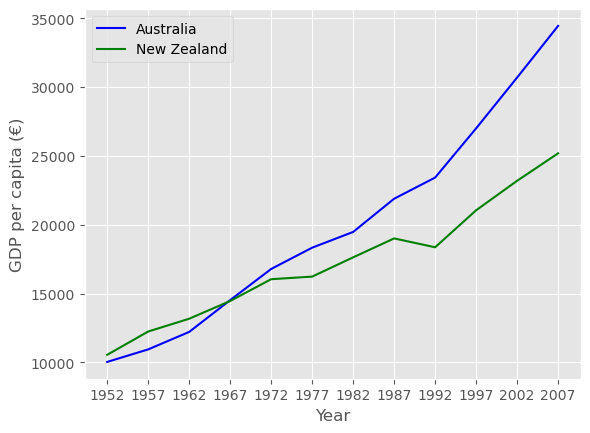

In [14]:
# Select the country to make a new subset of data
gdp_nz = data.loc["New Zealand"]

# plot with different linestyles
# Using plot like this will put both on the same figure
plt.plot(years, gdp_australia, 'b-', label="Australia")
plt.plot(years, gdp_nz, 'g-', label="New Zealand")

# Create legend (info box about what colour and type corresponds to what data)
plt.legend(loc="upper left")
plt.xlabel("Year")
plt.ylabel("GDP per capita (€)") # altcode 0128 for €


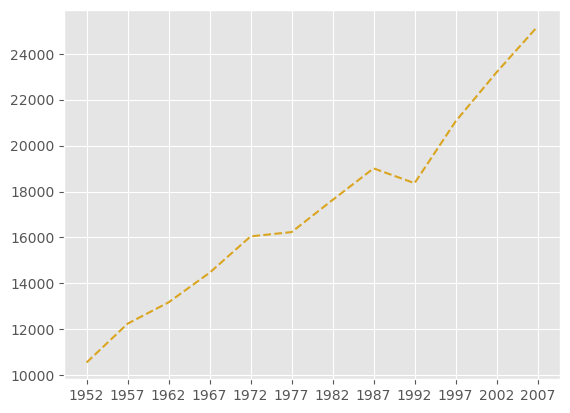

In [16]:
# You can also explicitly refer to colour and linestyle as seperate arguments
# I chose goldenrod as I am familiar with some of the colour names in matplotlib
plt.plot(years, gdp_nz, color="goldenrod", linestyle="--", label="New Zealand")

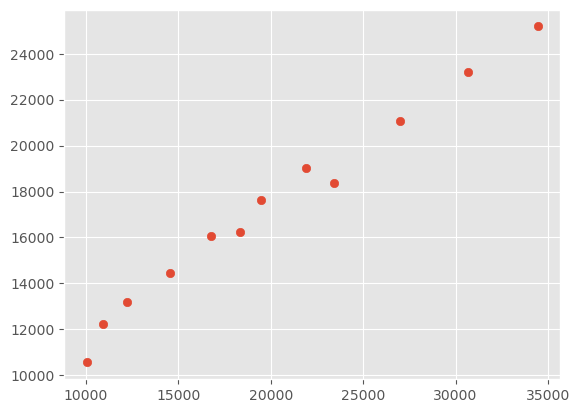

In [17]:
# Scatter plot of the gdp of australia vs the gdp of new zealand
plt.scatter(gdp_australia, gdp_nz)

<Axes: xlabel='Australia', ylabel='New Zealand'>

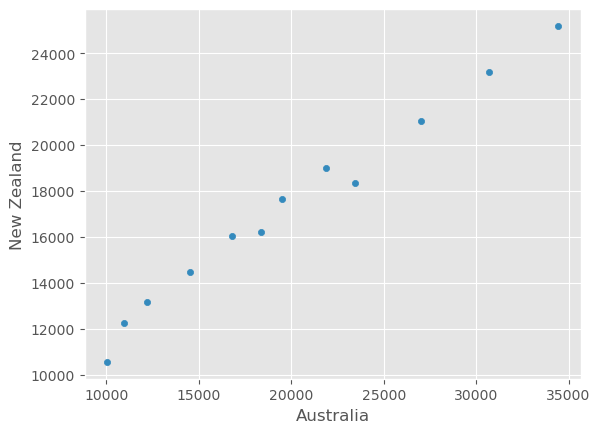

In [18]:
# We can also do this without making new variables for australia and NZ gdp by using the transpose method
# Tranpose (T) will change it so that the columns are Australia and New Zealand 
# This means we can ask matplotlib to refer to them by name to be able to plot them
data.T.plot.scatter(x = "Australia", y = "New Zealand")

In [25]:
# Looking at the transposed version to understand why this happens
data.T

country,Australia,New Zealand
1952,10039.59564,10556.57566
1957,10949.64959,12247.39532
1962,12217.22686,13175.67800
1967,14526.12465,14463.91893
1972,16788.62948,16046.03728
1977,18334.19751,16233.71770
1982,19477.00928,17632.41040
1987,21888.88903,19007.19129
1992,23424.76683,18363.32494
1997,26997.93657,21050.41377


(array([-2.,  0.,  2.,  4.,  6.,  8., 10., 12.]),
 [Text(-2.0, 0, 'gdpPercap_2002'),
  Text(0.0, 0, 'gdpPercap_1952'),
  Text(2.0, 0, 'gdpPercap_1962'),
  Text(4.0, 0, 'gdpPercap_1972'),
  Text(6.0, 0, 'gdpPercap_1982'),
  Text(8.0, 0, 'gdpPercap_1992'),
  Text(10.0, 0, 'gdpPercap_2002'),
  Text(12.0, 0, '')])

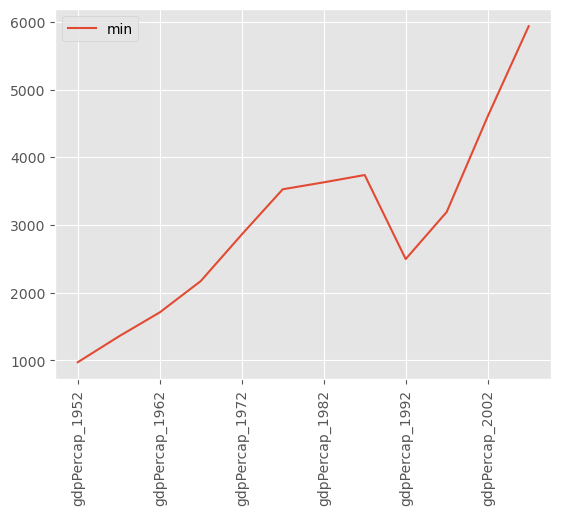

In [40]:
# Can you fill the blanks to make a minimum gdp per capita plot over time for all countries?
# data_europe = pd.read_csv('data/gapminder_gdp_europe.csv', index_col='country')
# data_europe.____.plot(label='min')
# plt.legend(loc='best')
# plt.xticks(rotation=90)



data_europe = pd.read_csv('data/gapminder_gdp_europe.csv', index_col='country')
data_europe.min().plot(label='min')
plt.legend(loc='best')
plt.xticks(rotation=90)


(array([-2.,  0.,  2.,  4.,  6.,  8., 10., 12.]),
 [Text(-2.0, 0, 'gdpPercap_2002'),
  Text(0.0, 0, 'gdpPercap_1952'),
  Text(2.0, 0, 'gdpPercap_1962'),
  Text(4.0, 0, 'gdpPercap_1972'),
  Text(6.0, 0, 'gdpPercap_1982'),
  Text(8.0, 0, 'gdpPercap_1992'),
  Text(10.0, 0, 'gdpPercap_2002'),
  Text(12.0, 0, '')])

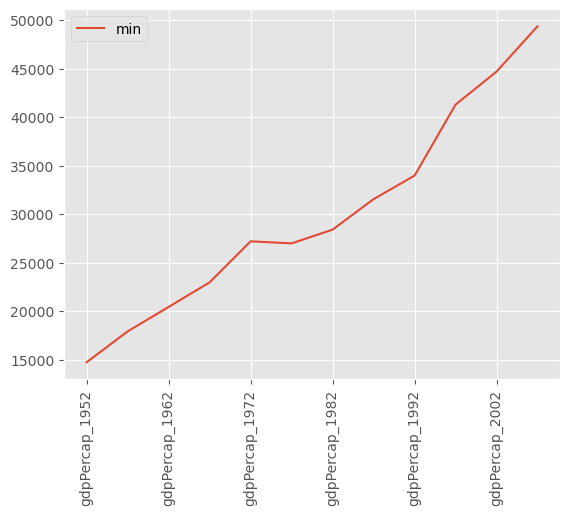

In [41]:
# Can you change it to work for the maximum gdp over time for all countries?
data_europe = pd.read_csv('data/gapminder_gdp_europe.csv', index_col='country')
data_europe.max().plot(label='min')
plt.legend(loc='best')
plt.xticks(rotation=90)

<Axes: xlabel='Australia', ylabel='New Zealand'>

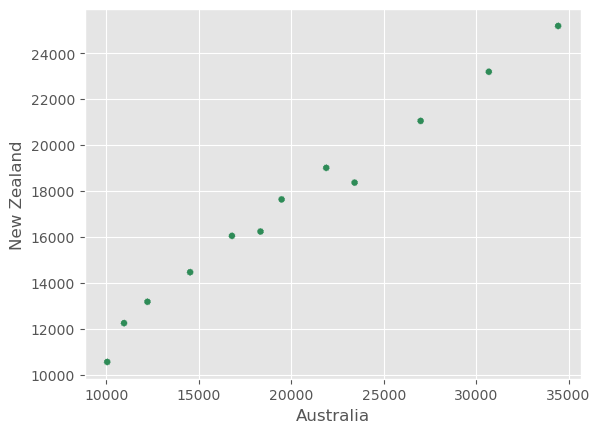

In [43]:
# Can you replot this with a custom colour and custom marker/style?
# https://matplotlib.org/stable/gallery/color/named_colors.html
# data.T.plot.scatter(x = "Australia", y = "New Zealand")
data.T.plot.scatter(x = "Australia", y = "New Zealand", color = "seagreen", linestyle = ":")